In [2]:
# Set up the state
from langgraph.graph import MessagesState, START, END
from langgraph.types import Command, interrupt
from langchain_core.messages import AIMessage, HumanMessage, ToolCall

from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from pydantic import BaseModel
from langchain_tavily import TavilySearch
# from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display


In [19]:
@tool
def search(location:str):
    """Call to get the weather at a location."""
    query = f"weather in {location}"
    print(f"Performing web search for: {query}")
    web_search_tool = TavilySearch(max_results=1, include_answer=True)
    search_response = web_search_tool.invoke({"query":query})

    return search_response

@tool
def ask_human(question):
    """Ask human a question"""
    print("Asking human")
    human_response = interrupt(question)
    return human_response

In [20]:
def build_model():
    llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
    return llm.bind_tools([search, ask_human])

In [21]:
def run_agent(state):
    print("Running Agent")
    model = build_model()
    response = model.invoke(state['query'])

    if response.tool_calls:
        tool_call = response.tool_calls[0]
        if tool_call['name'] == "ask_human":
            human_response = ask_human.invoke(tool_call['args'])
            search_response = search.invoke({'location':human_response})
            state['web_search_response'] = search_response
    else:
        state['agent_response'] = response.content
    return state

In [22]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict

class HumanInLoopState(TypedDict):
    """State for the human in loop workflow."""
    query:str
    agent_response:AIMessage
    web_search_response: str | dict

workflow = StateGraph(HumanInLoopState)

workflow.add_node("run_agent", run_agent)
workflow.add_edge(START, "run_agent")
workflow.add_edge("run_agent", END)


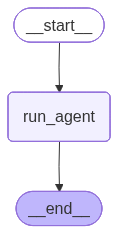

In [23]:
memory = InMemorySaver()
app = workflow.compile(checkpointer=memory)

display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
load_dotenv()
config = {"configurable": {"thread_id": "2"}}
response = app.invoke({
        "query": "Ask the user where they are, then look up the weather there"
    },
    config=config)

print(response)

Running Agent
Asking human
{'query': 'Ask the user where they are, then look up the weather there', '__interrupt__': [Interrupt(value='Where are you currently located?', id='b4d6517bc52cbfd37b0f3840097ce4c9')]}


In [25]:
response = app.invoke(Command(resume="Mars"), config=config)

print("\n\n======== Agent Response ======== \n")
print(response['web_search_response']['answer'])

Running Agent
Asking human
Performing web search for: weather in Mars


======== Agent Response ======== 

Mars has extreme temperatures, averaging -63°C (-81°F) at night and 20°C (68°F) during the day. Dust storms can cover the entire planet. The atmosphere is thin, mostly carbon dioxide.
